In [3]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 7.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
import warnings
warnings.filterwarnings("ignore")
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:
#Load Data set
df = pd.read_excel("P652-Dataset.xlsx")

In [6]:
print(df.head())

                                     title  rating  \
0                         Horrible product       1   
1  Camera quality is not like 48 megapixel       3   
2                                  Overall       4   
3                         A big no from me       1   
4            Put your money somewhere else       1   

                                                body  
0  Very disappointed with the overall performance...  
1                              Camera quality is low  
2  Got the mobile on the launch date,Battery must...  
3  1. It doesn't work with 5.0GHz WiFi frequency....  
4  Not worth buying....faulty software, poor disp...  


In [7]:
df.shape

(1440, 3)

In [8]:
df.columns

Index(['title', 'rating', 'body'], dtype='object')

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB
None


In [10]:
df.isna().sum()

title     0
rating    0
body      0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
print(df.describe())

            rating
count  1440.000000
mean      3.173611
std       1.584453
min       1.000000
25%       1.000000
50%       4.000000
75%       5.000000
max       5.000000


In [13]:
df.duplicated().sum()

0

In [14]:
df["review"] = df["title"] + " " + df["body"]

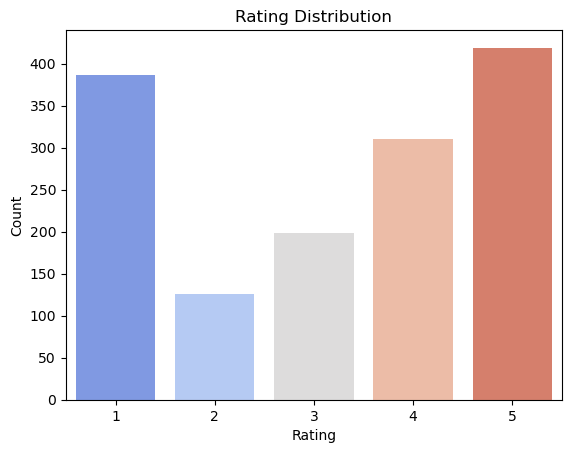

In [15]:
#Rating Distribution
plt.figure()
sns.countplot(x=df['rating'],palette='coolwarm')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [16]:
print("Average Rating:", round(df['rating'].mean(),2))

Average Rating: 3.17


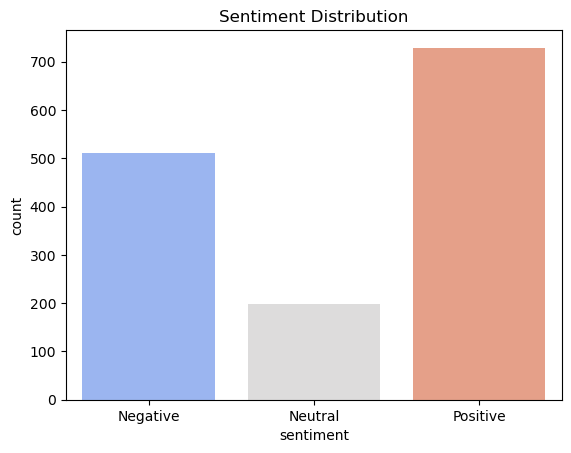

In [17]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(sentiment_label)

sns.countplot(x=df['sentiment'],palette='coolwarm')
plt.title("Sentiment Distribution")
plt.show()

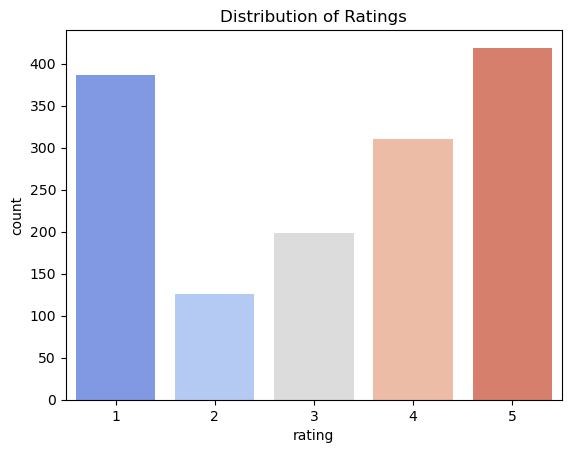

In [18]:
sns.countplot(x='rating', data=df, palette='coolwarm')
plt.title("Distribution of Ratings")
plt.show()


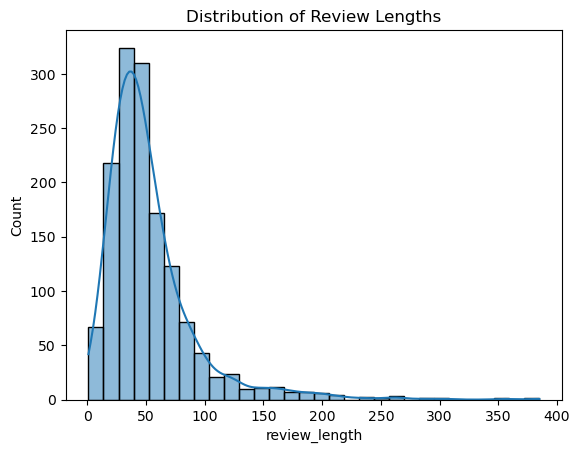

In [19]:
#Distribution of Review Lengths
df['review_length'] = df['body'].apply(lambda x: len(str(x).split()))

sns.histplot(df['review_length'], bins=30, kde=True)
plt.title("Distribution of Review Lengths")
plt.show()

In [20]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\barka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\barka\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

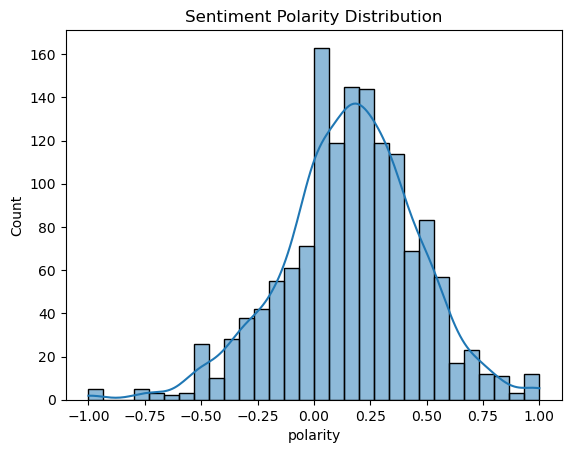

In [21]:
from textblob import TextBlob

df['polarity'] = df['body'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

sns.histplot(df['polarity'], bins=30, kde=True)
plt.title("Sentiment Polarity Distribution")
plt.show()


##TEXT EDA (Customer Behavior Analysis)

##TEXT CLEANING

In [22]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]","",text)
    return text

df["review"] = df["review"].apply(clean_text)

##Convert Text → Numbers
Machines cannot understand text.
We convert text using TF‑IDF.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["review"])
y = df["sentiment"]

##FEATURE ENGINEERING

In [24]:
df['title_length'] = df['title'].apply(len)
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))

In [25]:
df['rating_normalized'] = df['rating'] / 5

##Train Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

##Model Building

Logistic Regression

In [27]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

Naive Bayes Classifier

In [28]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

Random Forest

In [29]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

Support Vector Machine (SVM)

In [30]:
svm = LinearSVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

XGBoost / Gradient Boosting

In [31]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train_encoded)
y_pred = xgb_model.predict(X_test)

##Model Evaluation

In [32]:
accuracy_results = {
    "Naive Bayes": accuracy_score(y_test, nb_pred),
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "XGBoost": accuracy_score(y_test_encoded, y_pred)
}

accuracy_df = pd.DataFrame(list(accuracy_results.items()),
                           columns=["Model","Accuracy"])

print(accuracy_df)

                 Model  Accuracy
0          Naive Bayes  0.694444
1  Logistic Regression  0.788194
2                  SVM  0.795139
3        Random Forest  0.767361
4              XGBoost  0.760417


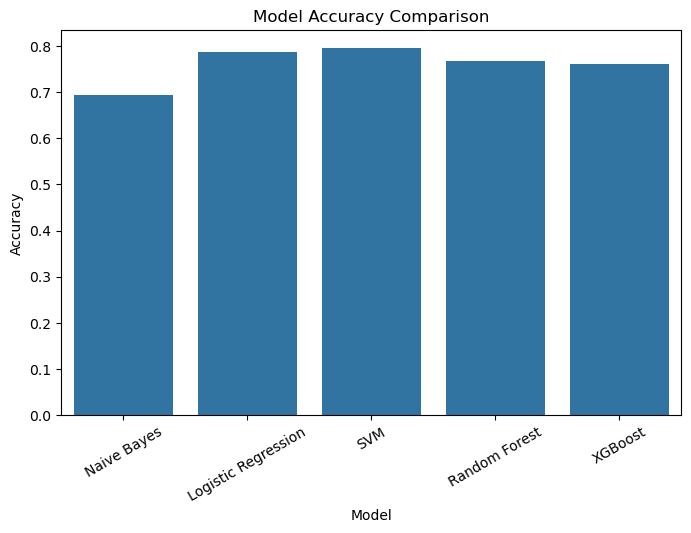

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=accuracy_df)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

In [34]:
print("Naive Bayes Classification Report\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Classification Report

              precision    recall  f1-score   support

    Negative       0.97      0.61      0.75       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.61      0.99      0.75       133

    accuracy                           0.69       288
   macro avg       0.53      0.54      0.50       288
weighted avg       0.65      0.69      0.64       288



In [35]:
print("Logistic Regression Classification Report\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Classification Report

              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87       111
     Neutral       1.00      0.02      0.04        44
    Positive       0.73      0.98      0.84       133

    accuracy                           0.79       288
   macro avg       0.87      0.62      0.58       288
weighted avg       0.83      0.79      0.73       288



In [36]:
print("SVM Classification Report\n")
print(classification_report(y_test, svm_pred))

SVM Classification Report

              precision    recall  f1-score   support

    Negative       0.87      0.86      0.87       111
     Neutral       0.50      0.11      0.19        44
    Positive       0.76      0.96      0.85       133

    accuracy                           0.80       288
   macro avg       0.71      0.65      0.63       288
weighted avg       0.76      0.80      0.76       288



In [37]:
print("Random Forest Classification Report\n")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report

              precision    recall  f1-score   support

    Negative       0.88      0.84      0.86       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.70      0.96      0.81       133

    accuracy                           0.77       288
   macro avg       0.53      0.60      0.56       288
weighted avg       0.66      0.77      0.71       288



In [38]:
print("XGBoost Classification Report\n")
print(classification_report(y_test_encoded, y_pred))

XGBoost Classification Report

              precision    recall  f1-score   support

           0       0.84      0.80      0.82       111
           1       0.40      0.18      0.25        44
           2       0.75      0.92      0.83       133

    accuracy                           0.76       288
   macro avg       0.66      0.63      0.63       288
weighted avg       0.73      0.76      0.74       288



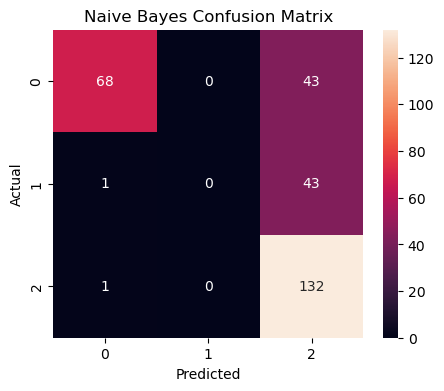

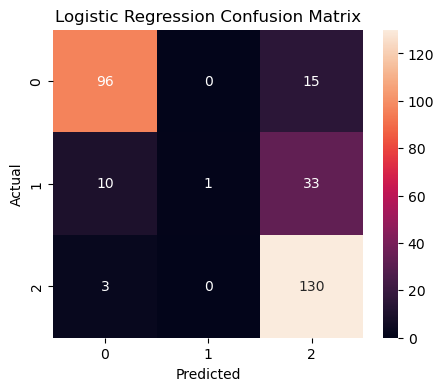

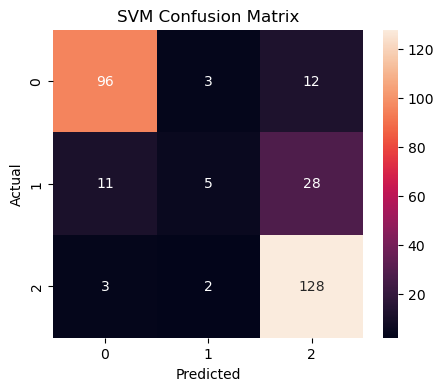

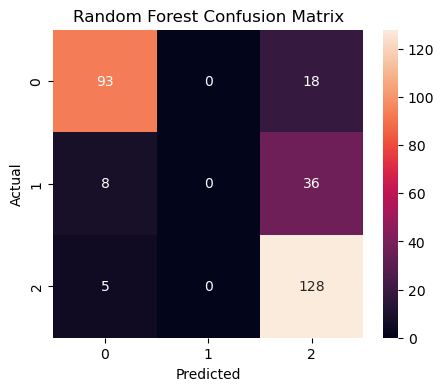

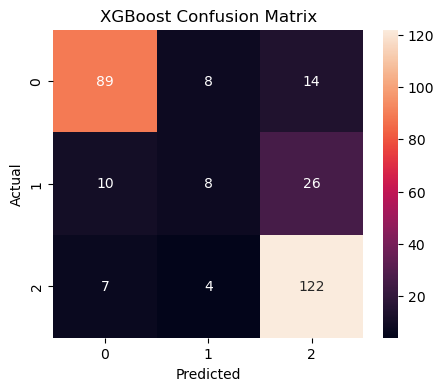

In [39]:
models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred,
    "Random Forest": rf_pred,
    "XGBoost" : y_pred
}

for name, pred in models.items():

    # Use y_test_encoded for XGBoost, otherwise use original y_test
    if name == "XGBoost":
        true_labels = y_test_encoded
    else:
        true_labels = y_test

    cm = confusion_matrix(true_labels, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [41]:
import pickle

# choose best model (SVM)
model = svm   # your trained SVM model

# save SVM model
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

# save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


In [42]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
